### Task 1

In [1]:
class GroceryManager:
    def __init__(self):
        self.inventory = {}

    def add_item(self, item, quantity, price):
        if item in self.inventory:
            self.inventory[item]['quantity'] += quantity
            self.inventory[item]['price'] = price
        else:
            self.inventory[item] = {'quantity': quantity, 'price': price}
        print(f"Added {quantity}x '{item}' at ${price:.2f} each.")

    def remove_item(self, item):
        if item in self.inventory:
            del self.inventory[item]
            print(f"Successfully removed '{item}'.")
        else:
            print(f"Error: '{item}' cannot be removed because it is not in the list.")

    def view_list(self):
        if not self.inventory:
            print("The grocery list is empty.")
            return
        
        print("\n--- Grocery List ---")
        for item, details in self.inventory.items():
            print(f"{item.capitalize()}: {details['quantity']} @ ${details['price']:.2f}")
        print("--------------------\n")

    def calculate_total(self):
        total_cost = sum(details['quantity'] * details['price'] for details in self.inventory.values())
        print(f"Total Cost: ${total_cost:.2f}")
        return total_cost

if __name__ == "__main__":
    manager = GroceryManager()
    manager.add_item("Apples", 5, 1.20)
    manager.add_item("Milk", 2, 3.50)
    manager.view_list()
    manager.calculate_total()
    
    manager.remove_item("Bread") 
    manager.remove_item("Apples")
    manager.view_list()

Added 5x 'Apples' at $1.20 each.
Added 2x 'Milk' at $3.50 each.

--- Grocery List ---
Apples: 5 @ $1.20
Milk: 2 @ $3.50
--------------------

Total Cost: $13.00
Error: 'Bread' cannot be removed because it is not in the list.
Successfully removed 'Apples'.

--- Grocery List ---
Milk: 2 @ $3.50
--------------------



### Task 2


In [2]:
student_records = {
    '101': {'Name': 'Alice Johnson', 'Major': 'Computer Science', 'Grades': [88, 92, 95]},
    '102': {'Name': 'Bob Smith', 'Major': 'Physics', 'Grades': [75, 80, 78]},
    '103': {'Name': 'Charlie Davis', 'Major': 'Computer Science', 'Grades': [90, 96, 99]},
    '104': {'Name': 'Diana Prince', 'Major': 'Mathematics', 'Grades': [85, 89, 91]}
}

def get_highest_average_student(records):
    if not records:
        return None
        
    best_student = None
    highest_avg = -1
    
    for student_id, details in records.items():
        grades = details['Grades']
        avg = sum(grades) / len(grades) if grades else 0 
        
        if avg > highest_avg:
            highest_avg = avg
            best_student = details['Name']
            
    return best_student

def search_by_major(records, major_name):
    """Prints all students enrolled in a specific major."""
    print(f"\n--- Students enrolled in {major_name} ---")
    found = False
    
    for student_id, details in records.items():
        if details['Major'].lower() == major_name.lower():
            print(f"- {details['Name']} (ID: {student_id})")
            found = True
            
    if not found:
        print("No students found for this major.")
    print("---------------------------------------")

if __name__ == "__main__":
    top_student = get_highest_average_student(student_records)
    print(f"Student with the highest average: {top_student}")
    
    search_by_major(student_records, 'Computer Science')
    search_by_major(student_records, 'Biology')

Student with the highest average: Charlie Davis

--- Students enrolled in Computer Science ---
- Alice Johnson (ID: 101)
- Charlie Davis (ID: 103)
---------------------------------------

--- Students enrolled in Biology ---
No students found for this major.
---------------------------------------


### Task 3

In [ ]:
pip install opencv-python

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


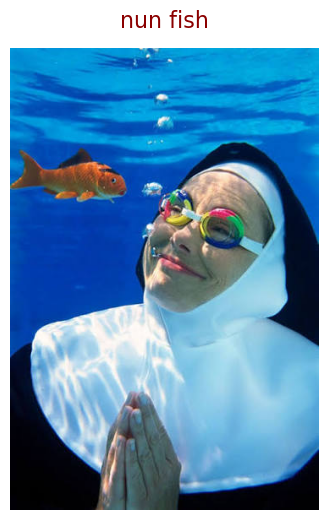

In [5]:
import cv2
import matplotlib.pyplot as plt

def load_and_visualize_image(image_path):
    image = cv2.imread(image_path)

    if image is None:
        print(f"Error: Image not found at path '{image_path}'.")
    else:
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(8, 6))
        plt.axis('off')
        plt.title('nun fish', fontsize=16, color='darkred', pad=15)
        plt.imshow(image_rgb)
        plt.show()

if __name__ == "__main__":
    target_image_path = 'imgs/nun.jpg' 
    load_and_visualize_image(target_image_path)

### Task 4

Canvas Dimensions: 800x800
Exact Center Coordinates: (400, 400)


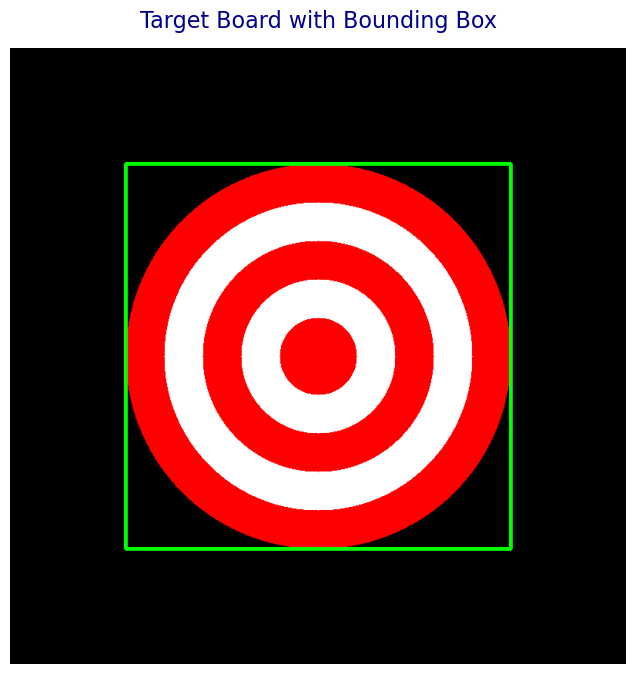

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

height, width = 800, 800
canvas = np.zeros((height, width, 3), dtype=np.uint8)

center_x, center_y = width // 2, height // 2
print(f"Canvas Dimensions: {width}x{height}")
print(f"Exact Center Coordinates: ({center_x}, {center_y})")

radii = [250, 200, 150, 100, 50]
colors = [
    (255, 0, 0),    
    (255, 255, 255),
    (255, 0, 0),    
    (255, 255, 255),
    (255, 0, 0)     
]

for radius, color in zip(radii, colors):
    cv2.circle(canvas, (center_x, center_y), radius, color, thickness=-1)

outer_radius = radii[0]
top_left = (center_x - outer_radius, center_y - outer_radius)
bottom_right = (center_x + outer_radius, center_y + outer_radius)
bbox_color = (0, 255, 0) 

cv2.rectangle(canvas, top_left, bottom_right, bbox_color, thickness=4)

plt.figure(figsize=(8, 8))
plt.imshow(canvas)
plt.title('Target Board with Bounding Box', fontsize=16, color='darkblue', pad=15)
plt.axis('off')
plt.show()

### Task 5

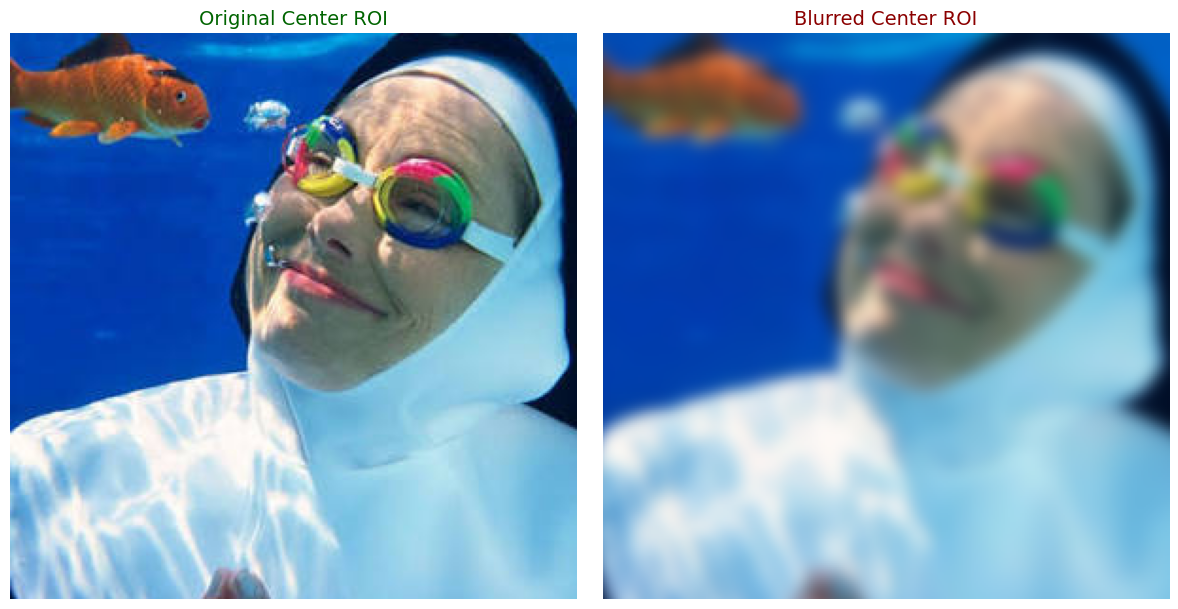

In [ ]:
import cv2
import matplotlib.pyplot as plt

def extract_and_compare_roi(image_path):
    image = cv2.imread(image_path)
    
    if image is None:
        print(f"Error: Image not found at path '{image_path}'.")
        return

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    blurred_image = cv2.GaussianBlur(image_rgb, (25, 25), 0)

    height, width = image_rgb.shape[:2]
    center_y, center_x = height // 2, width // 2
    
    y1, y2 = center_y - 150, center_y + 150
    x1, x2 = center_x - 150, center_x + 150

 
    roi_original = image_rgb[y1:y2, x1:x2]
    roi_blurred = blurred_image[y1:y2, x1:x2]

    
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

   
    axes[0].imshow(roi_original)
    axes[0].set_title('Original Center ROI', fontsize=14, color='darkgreen')
    axes[0].axis('off')

    
    axes[1].imshow(roi_blurred)
    axes[1].set_title('Blurred Center ROI', fontsize=14, color='darkred')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    extract_and_compare_roi('imgs/nun.jpg')

### Task 6

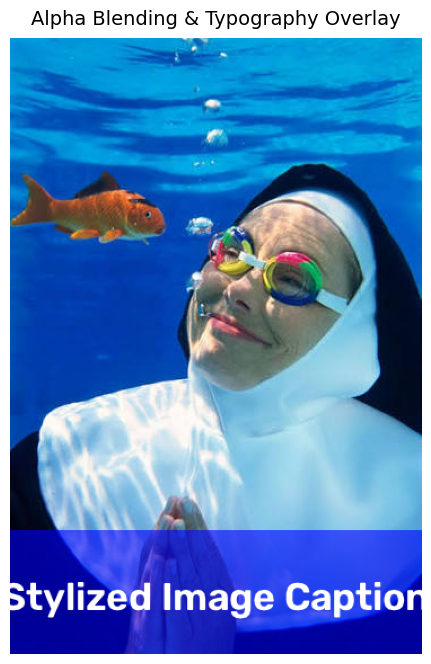

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def create_stylized_caption(image_path):
    image = cv2.imread(image_path)
    if image is None:
        print(f"Error: Image not found at '{image_path}'.")
        return
        
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    overlay = image_rgb.copy()
    final_image = image_rgb.copy()
    height, width = image_rgb.shape[:2]
    y_start = int(height * 0.8)
    cv2.rectangle(overlay, (0, y_start), (width, height), (0, 0, 255), thickness=-1)
    alpha = 0.6
    cv2.addWeighted(overlay, alpha, final_image, 1 - alpha, 0, final_image)
    title_text = "Stylized Image Caption"
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 1.2
    thickness = 3
    color = (255, 255, 255) 
    
    text_size = cv2.getTextSize(title_text, font, font_scale, thickness)[0]
    text_x = (width - text_size[0]) // 2
    text_y = y_start + ((height - y_start) + text_size[1]) // 2
    
    cv2.putText(final_image, title_text, (text_x, text_y), font, font_scale, color, thickness)
    
    plt.figure(figsize=(10, 8))
    plt.imshow(final_image)
    plt.title('Alpha Blending & Typography Overlay', fontsize=14, pad=10)
    plt.axis('off')
    plt.show()

if __name__ == "__main__":
    create_stylized_caption('imgs/nun.jpg')

### Task 7

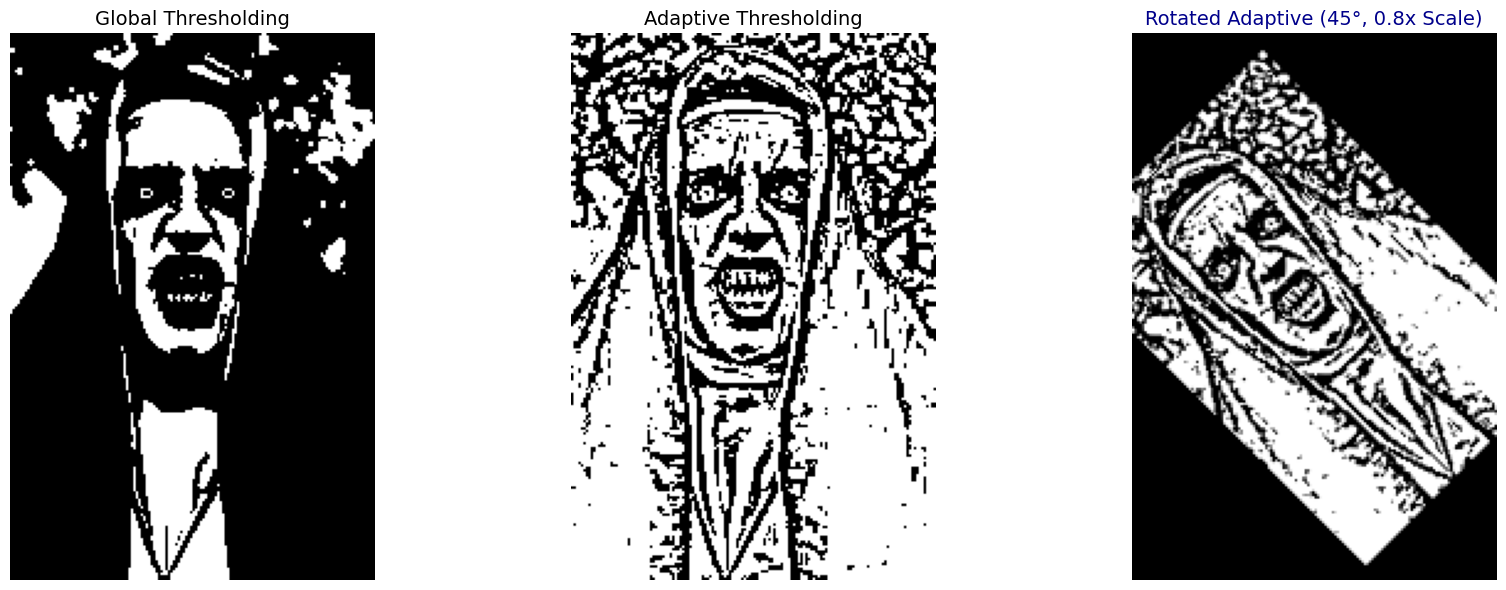

In [12]:
import cv2
import matplotlib.pyplot as plt

def apply_thresholds_and_rotate(image_path):
    gray_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    if gray_image is None:
        print(f"Error: Image not found at '{image_path}'.")
        return

    _, global_thresh = cv2.threshold(gray_image, 127, 255, cv2.THRESH_BINARY)

    adaptive_thresh = cv2.adaptiveThreshold(
        gray_image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
        cv2.THRESH_BINARY, 11, 2
    )

    height, width = adaptive_thresh.shape
    center = (width // 2, height // 2)
    
    rotation_matrix = cv2.getRotationMatrix2D(center, 45, 0.8)
    
    rotated_image = cv2.warpAffine(adaptive_thresh, rotation_matrix, (width, height))

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(global_thresh, cmap='gray')
    axes[0].set_title('Global Thresholding', fontsize=14)
    axes[0].axis('off')

    axes[1].imshow(adaptive_thresh, cmap='gray')
    axes[1].set_title('Adaptive Thresholding', fontsize=14)
    axes[1].axis('off')
    
    axes[2].imshow(rotated_image, cmap='gray')
    axes[2].set_title('Rotated Adaptive (45°, 0.8x Scale)', fontsize=14, color='darkblue')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    apply_thresholds_and_rotate('imgs/nun2.jpg')

### Task 8

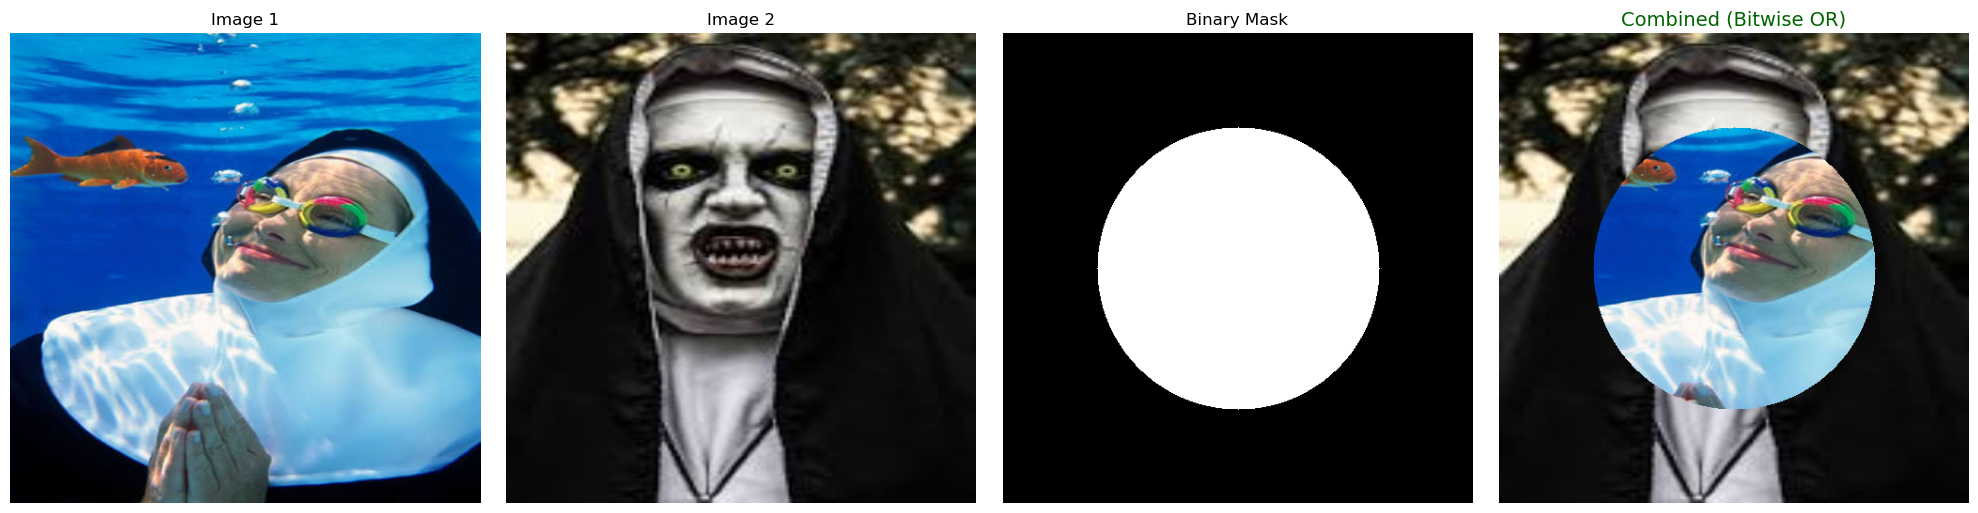

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def bitwise_masking(image1_path, image2_path):
    img1 = cv2.imread(image1_path)
    img2 = cv2.imread(image2_path)
    
    if img1 is None or img2 is None:
        print("Error: One or both image paths are invalid.")
        return

    img1_rgb = cv2.cvtColor(cv2.resize(img1, (500, 500)), cv2.COLOR_BGR2RGB)
    img2_rgb = cv2.cvtColor(cv2.resize(img2, (500, 500)), cv2.COLOR_BGR2RGB)
    mask = np.zeros((500, 500), dtype=np.uint8)
    center = (250, 250)
    radius = 150
    cv2.circle(mask, center, radius, 255, thickness=-1)
    foreground = cv2.bitwise_and(img1_rgb, img1_rgb, mask=mask)
    mask_inv = cv2.bitwise_not(mask)
    background = cv2.bitwise_and(img2_rgb, img2_rgb, mask=mask_inv)
    combined_image = cv2.bitwise_or(foreground, background)
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    axes[0].imshow(img1_rgb)
    axes[0].set_title('Image 1', fontsize=12)
    axes[0].axis('off')

    axes[1].imshow(img2_rgb)
    axes[1].set_title('Image 2', fontsize=12)
    axes[1].axis('off')

    axes[2].imshow(mask, cmap='gray')
    axes[2].set_title('Binary Mask', fontsize=12)
    axes[2].axis('off')

    axes[3].imshow(combined_image)
    axes[3].set_title('Combined (Bitwise OR)', fontsize=14, color='darkgreen')
    axes[3].axis('off')

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    bitwise_masking('imgs/nun.jpg', 'imgs/nun2.jpg')

### Task 9

In [15]:
import cv2
import pandas as pd

def profile_image_statistics(image_path):
    image = cv2.imread(image_path)
    
    if image is None:
        print(f"Error: Image not found at '{image_path}'.")
        return
        
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    r_channel, g_channel, b_channel = cv2.split(image_rgb)
    r_flat = r_channel.flatten()
    g_flat = g_channel.flatten()
    b_flat = b_channel.flatten()

    df = pd.DataFrame({
        'Red': r_flat,
        'Green': g_flat,
        'Blue': b_flat
    })

    summary = df.describe()

    print(f"\n--- Statistical Profile for '{image_path}' ---")
    print(summary)
    print("--------------------------------------------------\n")

# --- Quick Test ---
if __name__ == "__main__":
    profile_image_statistics('imgs/nun.jpg')


--- Statistical Profile for 'imgs/nun.jpg' ---
                 Red          Green           Blue
count  199655.000000  199655.000000  199655.000000
mean       65.695179     123.682042     167.472019
std        74.445200      68.254057      72.331452
min         0.000000       0.000000       0.000000
25%         1.000000      69.000000     119.000000
50%        11.000000     128.000000     195.000000
75%       125.000000     181.000000     223.000000
max       255.000000     255.000000     255.000000
--------------------------------------------------

